In [1]:
#------------  VARIANCE  THRESHOLD

 # Elimine les variables dont la variance est inférieure à un certain seuil.

In [2]:
from sklearn.feature_selection import VarianceThreshold

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

(150, 4)


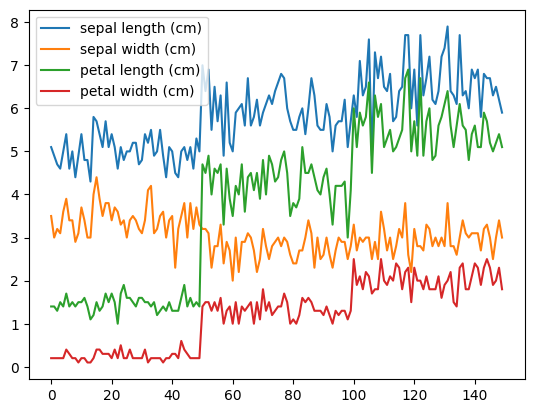

In [4]:
iris = load_iris()

x = iris.data
y = iris.target
# on charge le dataset iris à partir de la fonction load_iris de scikit-learn,
# et on sépare les données en variables explicatives (x) et variable cible (y)      

print(x.shape)
plt.plot(x)
plt.legend(iris.feature_names)

In [5]:
#          calcul des variance

In [ ]:
x.var(axis=0)
# on calcule la variance de chaque variable explicative en utilisant la méthode var de NumPy,

array([0.68112222, 0.18871289, 3.09550267, 0.57713289])

In [ ]:
selector = VarianceThreshold(threshold=0.2)
# cette ligne crée un objet VarianceThreshold avec un seuil de 0.2, ce qui signifie que les variables dont la variance est inférieure à 0.2 seront éliminées du dataset
selector.fit_transform(x)
selector.get_support()

array([ True, False,  True,  True])

In [ ]:
np.array(iris.feature_names)[selector.get_support()]
# on affiche les noms des variables qui ont été retenues après l'élimination 
# des variables à faible variance, en utilisant la méthode get_support de l'objet VarianceThreshold pour obtenir un masque booléen des variables retenues, et en utilisant ce masque pour indexer les noms des variables dans le dataset iris

array(['sepal length (cm)', 'petal length (cm)', 'petal width (cm)'],
      dtype='<U17')

In [9]:
#--------------   SELECTKBEST

# Sélectionne les K variables X dont les score du test de dépendance avec y est le plus élevé.

In [21]:
from sklearn.feature_selection import SelectKBest, chi2

In [11]:
chi2(x, y)

(array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ]),
 array([4.47651499e-03, 1.56395980e-01, 5.53397228e-26, 2.75824965e-15]))

In [ ]:
selector = SelectKBest(chi2, k=2)
# cette ligne crée un objet SelectKBest en utilisant le test du chi2 comme fonction de score, et en spécifiant que nous voulons sélectionner les 2 meilleures variables (k=2)
selector.fit_transform(x, y)
# on applique la méthode fit_transform de l'objet SelectKBest pour ajuster le modèle aux données (x, y) et transformer les données en ne conservant que les 2 meilleures variables sélectionnées par le test du chi2
selector.get_support()
# on utilise la méthode get_support de l'objet SelectKBest pour obtenir un masque booléen des variables sélectionnées, qui indique quelles variables ont été retenues après la sélection basée sur le test du chi2

array([False, False,  True,  True])

In [13]:
#----------y   SelctFromModel


# Entraine un estimateur puis sélectionne les variables les plus importantes pour cet estimateur.

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import SGDClassifier
# cette ligne crée un objet SelectFromModel en utilisant un classifieur linéaire stochastique (SGDClassifier) comme estimateur de base, et en spécifiant que nous voulons sélectionner les variables dont l'importance est supérieure à 0.5 (threshold=0.5)

In [15]:
selector = SelectFromModel(SGDClassifier(random_state=0),
                          threshold='mean')

selector.fit_transform(x, y)
selector.get_support()

array([False, False,  True,  True])

In [ ]:
selector.estimator_.coef_
# on affiche les coefficients du modèle entraîné par le classifieur linéaire stochastique (SGDClassifier) utilisé comme estimateur de base dans l'objet SelectFromModel, ce qui permet d'identifier l'importance de chaque variable explicative dans la prédiction de la variable cible (y) en fonction des coefficients associés à chaque variable dans le modèle entraîné.

array([[  3.52056329,  11.04176668, -16.48263722,  -7.36117779],
       [ -5.48888269, -58.79616709,  22.88584985, -54.14457159],
       [-81.28026953, -75.17372078, 130.76437145, 131.39608339]])

In [ ]:
from sklearn.feature_selection import RFE, RFECV
# RFE (Recursive Feature Elimination) est une méthode de sélection de variables qui élimine récursivement les variables les moins importantes en fonction d'un modèle d'estimation, tandis que RFECV (Recursive Feature Elimination with Cross-Validation) est une variante de RFE qui utilise la validation croisée pour évaluer les performances du modèle à chaque étape de l'élimination des variables, afin de déterminer le nombre optimal de variables à sélectionner.
from sklearn.model_selection import GridSearchCV
# GridSearchCV est une technique de recherche en grille qui permet d'optimiser les hyperparamètres d'un modèle en évaluant les performances du modèle pour différentes combinaisons d'hyperparamètres, en utilisant la validation croisée pour éviter le surapprentissage et trouver les meilleurs paramètres pour le modèle.

In [ ]:
selector = RFECV(SGDClassifier(random_state=0),
                 step=1,
                 min_features_to_select=2, cv=5)
# cette ligne crée un objet RFECV en utilisant un classifieur linéaire stochastique (SGDClassifier) comme estimateur de base, en spécifiant que nous voulons éliminer une variable à la fois (step=1), que nous voulons sélectionner au moins 2 variables (min_features_to_select=2), et que nous voulons utiliser une validation croisée à 5 plis (cv=5) pour évaluer les performances du modèle à chaque étape de l'élimination des variables.



In [19]:
selector.fit(x, y)
selector.ranking_
#selector.grid_scores_

array([2, 1, 1, 1])